 Column Locations      Variable Name and Label
----------------------------------------------------------------------
       1 -  5     id    /*sequential id runs from 1 to 5225 */
       7 -  7     nearc2  /*grew up near 2-yr college*/
      10 - 10     nearc4  /*grew up near 4-yr college*/
      12 - 13     nearc4a /*grew up near 4-yr public college*/
      15 - 16     nearc4b /*grew up near 4-yr priv college*/
      18 - 19     ed76  /*educ in 1976*/
      21 - 22     ed66  /*educ in 1966*/
      24 - 25     age76  /* age in 1976
      27 - 31     daded /*dads education missing=avg*/
      33 - 33     nodaded /* 1 if dad ed imputed*/
      35 - 39     momed /*moms education*/
      41 - 41     nomomed /* 1 if mom ed imputed*/
      43 - 54     weight  /* nls weight for 1976 cross-section */
      56 - 56     momdad14 /*1 if live with mom and dad age 14*/
      58 - 58     sinmom14 /*lived with single mom age 14*/
      60 - 60     step14  /*lived step parent age 14*/
      62 - 62     reg661 /* dummy for region=1 in 1966 */
      64 - 64     reg662  /* dummy for region=2 in 1966 */
      66 - 66     reg663  /* dummy for region=3 in 1966 */
      68 - 68     reg664
      70 - 70     reg665
      72 - 72     reg666
      74 - 74     reg667
      76 - 76     reg668
      78 - 78     reg669  /* dummy for region=9 in 1966 */
      80 - 80     south66 /*lived in south in 1966*/
      82 - 82     work76 /* worked in 1976*/
      84 - 84     work78 /* worked in 1978*/
      86 - 97     lwage76  /*log wage (outliers trimmed) 1976 */
      99 -110     lwage78  /*log wage in 1978 outliers trimmed */
     112 -112     famed /*mom-dad education class 1-9*/
     114 -114     black  /* 1 if black*/
     116 -116     smsa76r /*in smsa in 1976*/
     118 -118     smsa78r /*in smsa in 1978*/
     120 -120     reg76r /*in south in 1976*/
     122 -122     reg78r /*in south in 1978*/
     124 -124     reg80r /* in south in 1980*/
     126 -126     smsa66r /* in smsa in 1966*/
     128 -132     wage76 /*raw wage cents per hour 1976*/
     134 -138     wage78
     140 -144     wage80
     146 -146     noint78 /*1 if noninterview in 78*/
     148 -148     noint80
     150 -150     enroll76 /*1 if enrolled in 76*/
     152 -152     enroll78
     154 -154     enroll80
     156 -157     kww  /*the kww score*/
     159 -161     iq  /* a normed iq score*/
     163 -163     marsta76 /*mar status in 1976 1=married, sp. present *
     165 -165     marsta78
     167 -167     marsta80
     169 -169     libcrd14   /*1 if lib card in home age 14*/

**Treatment** — years of education  
**Outcome** — wages  
**Instrument** — proximity to college  


In [4]:
import pandas as pd
import numpy as np
# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# ---- 1. Define column names (same order as SAS input) ----
cols = [
    "id","nearc2","nearc4","nearc4a","nearc4b","ed76","ed66","age76",
    "daded","nodaded","momed","nomomed","weight","momdad14","sinmom14",
    "step14","reg661","reg662","reg663","reg664","reg665","reg666",
    "reg667","reg668","reg669","south66","work76","work78","lwage76",
    "lwage78","famed","black","smsa76r","smsa78r","reg76r","reg78r",
    "reg80r","smsa66r","wage76","wage78","wage80","noint78","noint80",
    "enroll76","enroll78","enroll80","kww","iq","marsta76","marsta78",
    "marsta80","libcrd14"
]

# ---- 2. Read flat file ----
# Adjust path and delimiter as needed (whitespace assumed)

df = pd.read_csv(
    "Data/nls.dat",
    sep=r"\s+",          # split on any whitespace
    names=cols,
    na_values=".",       # treat '.' as missing
    engine="python"
)
df.head()

,id,nearc2,nearc4,nearc4a,nearc4b,ed76,ed66,age76,daded,nodaded,...,noint80,enroll76,enroll78,enroll80,kww,iq,marsta76,marsta78,marsta80,libcrd14
0,2,0,0,0,0,7,5,29,9.94,1,...,0,0,0.0,0.0,15.0,NaN,1.0,1.0,1.0,0.0
1,3,0,0,0,0,12,11,27,8.00,0,...,0,0,0.0,0.0,35.0,93.0,1.0,4.0,4.0,1.0
2,4,0,0,0,0,12,12,34,14.00,0,...,1,0,NaN,NaN,42.0,103.0,1.0,NaN,NaN,1.0
3,5,1,1,1,0,11,11,27,11.00,0,...,0,0,NaN,0.0,25.0,88.0,1.0,NaN,5.0,1.0
4,6,1,1,1,0,12,12,34,8.00,0,...,1,0,0.0,NaN,34.0,108.0,1.0,1.0,NaN,0.0


In [5]:
df.describe()

,id,nearc2,nearc4,nearc4a,nearc4b,ed76,ed66,age76,daded,nodaded,...,noint80,enroll76,enroll78,enroll80,kww,iq,marsta76,marsta78,marsta80,libcrd14
count,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,3613.000000,...,3613.000000,3613.000000,3317.000000,3220.000000,3543.000000,2470.000000,3604.000000,3319.000000,3227.000000,3598.000000
mean,2609.781622,0.431774,0.678107,0.492112,0.185995,13.225298,10.742873,28.175201,10.002878,0.224190,...,0.106836,0.094658,0.065421,0.058385,33.489134,102.587854,2.357103,2.213619,2.104121,0.671762
std,1498.513199,0.495392,0.467267,0.500007,0.389157,2.749741,2.459085,3.171810,3.296021,0.417106,...,0.308948,0.292783,0.247304,0.234507,8.691808,15.445070,2.109638,2.005834,1.908883,0.469637
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,1.000000,1.000000,1.000000,0.000000
25%,1330.000000,0.000000,0.000000,0.000000,0.000000,12.000000,9.000000,25.000000,8.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,28.000000,93.000000,1.000000,1.000000,1.000000,0.000000
50%,2574.000000,0.000000,1.000000,0.000000,0.000000,13.000000,11.000000,28.000000,9.940000,0.000000,...,0.000000,0.000000,0.000000,0.000000,34.000000,104.000000,1.000000,1.000000,1.000000,1.000000
75%,3908.000000,1.000000,1.000000,1.000000,0.000000,16.000000,12.000000,31.000000,12.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,40.000000,113.000000,4.000000,4.000000,4.000000,1.000000
max,5225.000000,1.000000,1.000000,1.000000,1.000000,18.000000,18.000000,34.000000,18.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,56.000000,156.000000,6.000000,6.000000,6.000000,1.000000


If we compare our dataset with the info provided in the dataset card, we can see that we read correclty the data, as we have the same values for statistics.

## Instrumental Relevance

In [15]:
# Average education years for each nearc4
df.groupby("nearc4")["ed76"].mean()

nearc4
0    12.650903
1    13.497959
Name: ed76, dtype: float64

In [16]:
df.groupby("nearc4")["ed76"].median()

nearc4
0    12.0
1    13.0
Name: ed76, dtype: float64

In [19]:
from scipy import stats

group0 = df[df["nearc4"] == 0]["ed76"].dropna()
group1 = df[df["nearc4"] == 1]["ed76"].dropna()

t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)  # Welch test

print("t-statistic:", t_stat) # -8.534285082597062
print("p-value:", p_value) # 2.6203673326551105e-17

# Statisitcally significant difference

t-statistic: -8.534285082597062
p-value: 2.6203673326551105e-17


           nearc4    nearc2   nearc4a   nearc4b      ed76
nearc4   1.000000  0.125765  0.678195  0.329340  0.143941
nearc2   0.125765  1.000000  0.218294 -0.129466  0.051122
nearc4a  0.678195  0.218294  1.000000 -0.470527  0.154733
nearc4b  0.329340 -0.129466 -0.470527  1.000000 -0.025976
ed76     0.143941  0.051122  0.154733 -0.025976  1.000000


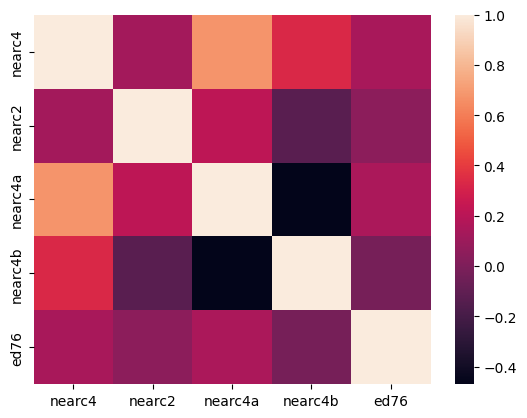

In [14]:
import seaborn as sns
import matplotlib as plt

corr = df[["nearc4","nearc2","nearc4a","nearc4b","ed76"]].corr()
sns.heatmap(corr)
print(corr)